In [1]:
from dotenv import load_dotenv
load_dotenv()

import importlib.metadata as metadata
import langchain

print(f"LangChain: {langchain.__version__}")
print(f"LangGraph: {metadata.version('langgraph')}")

LangChain: 1.3.11
LangGraph: 1.2.7


In [2]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="gpt-oss:120b-cloud", temperature=0)

# -- Alternatively, use Groq --------------------------------------------------
# from langchain_groq import ChatGroq
# llm = ChatGroq(model="llama-3.3-70b-versatile")
# ------------------------------------------------------------------------------

print("LLM ready.")

LLM ready.


In [3]:
from langchain_core.tools import tool

# Reusing familiar local tools from previous lessons
@tool
def get_weather(city: str) -> str:
    """Returns the current weather for a given city."""
    return f"The weather in {city} is sunny with a high of 28C."

@tool
def get_stock_price(ticker: str) -> str:
    """Returns the current stock price for a given ticker symbol.
    Use 'ZENSAR' for Zensar Technologies, 'GOOGL' for Google."""
    prices = {"ZENSAR": "527.90 INR", "GOOGL": "175.00 USD"}
    return prices.get(ticker.upper(), f"Unknown ticker: {ticker}")

TOOLS = [get_weather, get_stock_price]
print("Tools ready: get_weather, get_stock_price")

Tools ready: get_weather, get_stock_price


In [4]:
from typing import Annotated, TypedDict

from langchain_core.messages import AnyMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class AgentState(TypedDict):                               #    // AgentState is StateClass and messages is state variable
    # add_messages appends new messages instead of replacing the whole list
    messages: Annotated[list[AnyMessage], add_messages]

print("AgentState ready.")

AgentState ready.


In [5]:
#this call_llm is a  NODE or PythonFunction, it generally take state as Input and returns the Modified state as Output. In this case, it takes the messages from the state and returns a new message from the LLM.

def call_llm(state: AgentState) -> dict:
    """One graph node: call the LLM using the current messages."""
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

In [6]:
# Build the graph

simple_builder = StateGraph(AgentState)
simple_builder.add_node("assistant", call_llm)               #When ever this assistant node is called, it will call the call_llm function and return the modified state with new messages.


simple_builder.add_edge(START, "assistant")
simple_builder.add_edge("assistant", END)

simple_graph = simple_builder.compile()        #inside complie("Here we need to mention which memory we are using oinline/ssms/mongoDB etc")
print("Simple graph compiled: START -> assistant -> END")

Simple graph compiled: START -> assistant -> END


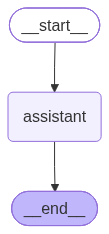

In [7]:
simple_graph

In [9]:
simple_result = simple_graph.invoke({
    "messages": [("user", "Explain LangGraph in one sentence.")]
})

print(simple_result["messages"][-1].content)
print()
print(f"Messages in final state: {len(simple_result['messages'])}")

LangGraph is a Python library that lets you build, visualize, and run flexible, state‑driven workflows of LLM‑powered agents and tools by defining nodes (functions) and edges (transitions) in a graph‑like structure.

Messages in final state: 2


In [10]:
for i, msg in enumerate(simple_result["messages"], 1):
    role = msg.__class__.__name__.replace("Message", "")
    text = str(msg.content)
    text = text[:90] + "..." if len(text) > 90 else text
    print(f"[{i}] {role}: {text}")

[1] Human: Explain LangGraph in one sentence.
[2] AI: LangGraph is a Python library that lets you build, visualize, and run flexible, state‑driv...


In [11]:
print(simple_graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	assistant(assistant)
	__end__([<p>__end__</p>]):::last
	__start__ --> assistant;
	assistant --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [12]:
from langgraph.prebuilt import ToolNode

llm_with_tools = llm.bind_tools(TOOLS)

def assistant(state: AgentState) -> dict:
    """Assistant node: call the model, allowing it to request tools."""
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


def route_after_assistant(state: AgentState) -> str:
    """Route to tools only when the model produced tool calls."""
    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "tools"
    return END

print("assistant node and router ready.")


assistant node and router ready.


Lets create another one -

In [14]:
tool_builder = StateGraph(AgentState)

tool_builder.add_node("tools", ToolNode(TOOLS))          #with help of LangGraph we have ToolNode, here we can pass list of tools and it will automatically handle the tool calls and return the modified state with new messages.
tool_builder.add_node("assistant", assistant)


tool_builder.add_edge(START, "assistant")   #I would like to start my GRAPH with START, and then it will call "assistant" node, and then it will check the route_after_assistant function, if it returns "tools" then it will call the tools node, otherwise it will go to END.
tool_builder.add_conditional_edges(
    "assistant",
    route_after_assistant,
    {
        "tools": "tools",    #Here it will check if the last message has tool_calls, if yes then it will call the tools node, otherwise it will go to END.
        END: END,
    },
)
tool_builder.add_edge("tools", "assistant")   #here we are adding edge from tools to assistant, so that after the tools node is called, it will again call the assistant node and then it will check the route_after_assistant function, if it returns "tools" then it will call the tools node, otherwise it will go to END.

tool_graph = tool_builder.compile()
print("Tool graph compiled: assistant <-> tools, with a conditional exit to END")

Tool graph compiled: assistant <-> tools, with a conditional exit to END


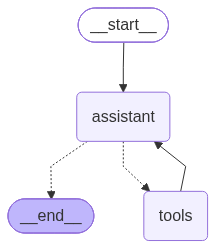

In [15]:
tool_graph

In [16]:
print(tool_graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	tools(tools)
	assistant(assistant)
	__end__([<p>__end__</p>]):::last
	__start__ --> assistant;
	assistant -.-> __end__;
	assistant -.-> tools;
	tools --> assistant;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [17]:
tool_result = tool_graph.invoke({
    "messages": [("user", "What is the weather in Pune and the Zensar stock price?")]
})

print("Final answer:")
print(tool_result["messages"][-1].content)

Final answer:
**Weather in Pune:** Sunny with a high of **28 °C**.  

**Zensar Technologies (ZENSAR) stock price:** **₹527.90**.
